# Assignment 1: Housing Price Prediction

IE500618 Machine Learning. Group 4: Emilie, David, Kristian.

We predict `SalePrice` for houses in Ames, Iowa, from `AmesHousing.csv`, and compare three regression models. The notebook follows the six steps in the assignment. The test set is not used before step 6.

## Step 1: Explore and understand the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.1f}".format)

RANDOM_STATE = 0

df = pd.read_csv("data/AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


### 1a Variables and data types

In [2]:
print("Rows, columns:", df.shape)
print()
print("Columns per data type:")
df.dtypes.value_counts()

Rows, columns: (2930, 82)

Columns per data type:


str        43
int64      28
float64    11
Name: count, dtype: int64

In [3]:
num_cols = df.select_dtypes(include="number").columns
print("Numerical columns:", len(num_cols))
num_cols

Numerical columns: 39


Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')

In [4]:
cat_cols = df.select_dtypes(exclude="number").columns
print("Text columns:", len(cat_cols))
cat_cols

Text columns: 43


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')

In [5]:
print("Different values in Order:", df["Order"].nunique())
print("Different values in PID:", df["PID"].nunique())
print("Different values in Lot Area:", df["Lot Area"].nunique())
print("Different values in MS SubClass:", df["MS SubClass"].nunique())

Different values in Order: 2930
Different values in PID: 2930
Different values in Lot Area: 1960
Different values in MS SubClass: 16


The thing to notice here is that columns like `Order` and `PID` are IDs, and not actual measurements like `Lot Area`. This is easy to see because `Order` and `PID` have 2930 different values, one for each house. `Lot Area` also has many values (1960), but some houses share the same size. `MS SubClass` has just 16 different values shared by all the houses, which makes it a code for house type and not an amount.

### 1b Distribution of SalePrice

In [6]:
print("SalePrice statistics:")
df["SalePrice"].describe()

SalePrice statistics:


count     2930.0
mean    180796.1
std      79886.7
min      12789.0
25%     129500.0
50%     160000.0
75%     213500.0
max     755000.0
Name: SalePrice, dtype: float64

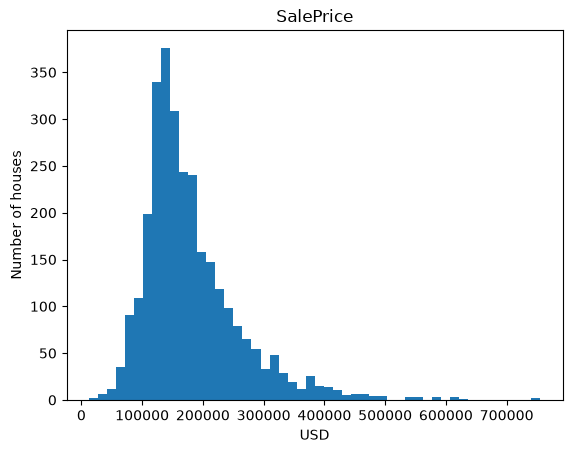

In [7]:
df["SalePrice"].plot.hist(bins=50)
plt.title("SalePrice")
plt.xlabel("USD")
plt.ylabel("Number of houses")
plt.show()

Most houses are sold between 100,000 and 200,000 USD. We also notice that a few _very expensive_ houses push the mean (180,796 USD) higher than the median (160,000).

### 1c Missing values

In [8]:
missing = df.isna().sum()
missing_pct = missing[missing > 0] / len(df) * 100 # Convert to percentage

print("Columns with missing values:", len(missing_pct))
missing_pct.sort_values(ascending=False)

Columns with missing values: 27


Pool QC          99.6
Misc Feature     96.4
Alley            93.2
Fence            80.5
Mas Vnr Type     60.6
Fireplace Qu     48.5
Lot Frontage     16.7
Garage Qual       5.4
Garage Cond       5.4
Garage Yr Blt     5.4
Garage Finish     5.4
Garage Type       5.4
Bsmt Exposure     2.8
BsmtFin Type 2    2.8
Bsmt Cond         2.7
Bsmt Qual         2.7
BsmtFin Type 1    2.7
Mas Vnr Area      0.8
Bsmt Full Bath    0.1
Bsmt Half Bath    0.1
BsmtFin SF 1      0.0
BsmtFin SF 2      0.0
Electrical        0.0
Total Bsmt SF     0.0
Bsmt Unf SF       0.0
Garage Area       0.0
Garage Cars       0.0
dtype: float64

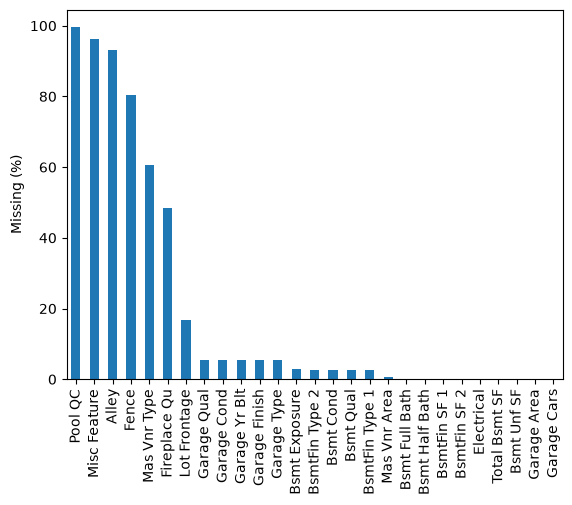

In [9]:
missing_pct.sort_values(ascending=False).plot.bar()
plt.ylabel("Missing (%)")
plt.show()

In [10]:
print("Houses with 0 fireplaces:", (df["Fireplaces"] == 0).sum())
print("Missing Fireplace Qu:", df["Fireplace Qu"].isna().sum())

Houses with 0 fireplaces: 1422
Missing Fireplace Qu: 1422


In [11]:
print("Houses with 0 pool area:", (df["Pool Area"] == 0).sum())
print("Missing Pool QC:", df["Pool QC"].isna().sum())

Houses with 0 pool area: 2917
Missing Pool QC: 2917


In [12]:
print("Houses with 0 garage area:", (df["Garage Area"] == 0).sum())
print("Missing Garage Type:", df["Garage Type"].isna().sum())
print("Missing Garage Qual:", df["Garage Qual"].isna().sum())

Houses with 0 garage area: 157
Missing Garage Type: 157
Missing Garage Qual: 159


27 columns have at least one missing value. Some are almost empty, like `Pool QC` (99.6 %), while others miss only one or two values. Most of them just mean the house doesn't have it, like 2917 houses missing `Pool QC` and 2917 houses having 0 pool area.

### 1d Unusual values or patterns

In [13]:
df.describe().T[["count", "min", "max"]].round() # Transpose (columns -> rows)

,count,min,max
Order,2930.0,1.0,2930.0
PID,2930.0,526301100.0,1007100110.0
MS SubClass,2930.0,20.0,190.0
Lot Frontage,2440.0,21.0,313.0
Lot Area,2930.0,1300.0,215245.0
Overall Qual,2930.0,1.0,10.0
Overall Cond,2930.0,1.0,9.0
Year Built,2930.0,1872.0,2010.0
Year Remod/Add,2930.0,1950.0,2010.0
Mas Vnr Area,2907.0,0.0,1600.0


Scanning the min and max values, `Garage Yr Blt` stands out with a max of 2207.

In [14]:
df[df["Garage Yr Blt"] > df["Yr Sold"]][["Year Built", "Garage Yr Blt", "Yr Sold"]]

,Year Built,Garage Yr Blt,Yr Sold
2180,2008,2008.0,2007
2260,2006,2207.0,2007


`Year Built` is easy to understand, so we check if newer houses really are more expensive.

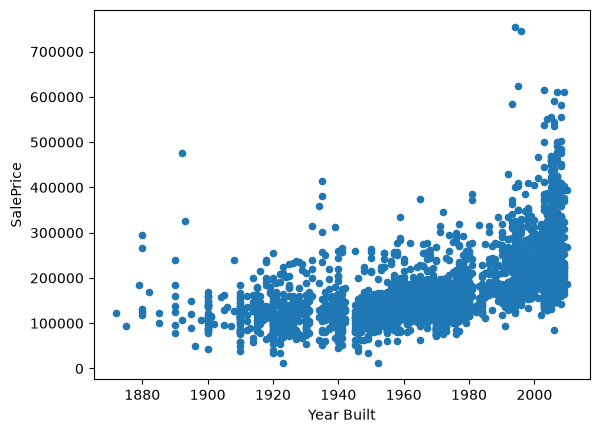

In [15]:
df.plot.scatter(x="Year Built", y="SalePrice")
plt.show()

Now we notice that the plot doesn't follow a straight line. Old houses are spread out, while the newer ones are more expensive and closer together. We can still identify 3 outliers: 1 house built before 1900 that sold for more than 400,000, and 2 houses that sold for more than 700,000.

In [16]:
df[(df["Year Built"] < 1900) & (df["SalePrice"] > 400000)][["Year Built", "SalePrice", "Overall Qual", "Gr Liv Area", "Neighborhood"]]

,Year Built,SalePrice,Overall Qual,Gr Liv Area,Neighborhood
2666,1892,475000,10,3608,OldTown


In [17]:
df[df["SalePrice"] > 700000][["Year Built", "SalePrice", "Overall Qual", "Gr Liv Area", "Neighborhood", "Sale Condition"]]

,Year Built,SalePrice,Overall Qual,Gr Liv Area,Neighborhood,Sale Condition
1760,1996,745000,10,4476,NoRidge,Abnorml
1767,1994,755000,10,4316,NoRidge,Normal


All three have quality 10 and a lot of living area, so these are real houses and not errors.

**But there's one other thing!** `Garage Yr Blt` has a max of 2207 for a house sold in 2007, which has to be a typo. That's a different kind of unusual value: an actual error in the data.

We can only find errors when we have something to check against, like a year in the future. A wrong but possible value can't be found from the data alone.

### 1e Relationships that may be useful for predicting house prices.

In [18]:
print("Correlation with SalePrice:")
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

Correlation with SalePrice:


SalePrice          1.0
Overall Qual       0.8
Gr Liv Area        0.7
Garage Cars        0.6
Garage Area        0.6
Total Bsmt SF      0.6
1st Flr SF         0.6
Year Built         0.6
Full Bath          0.5
Year Remod/Add     0.5
Garage Yr Blt      0.5
Mas Vnr Area       0.5
TotRms AbvGrd      0.5
Fireplaces         0.5
BsmtFin SF 1       0.4
Lot Frontage       0.4
Wood Deck SF       0.3
Open Porch SF      0.3
Half Bath          0.3
Bsmt Full Bath     0.3
2nd Flr SF         0.3
Lot Area           0.3
Bsmt Unf SF        0.2
Bedroom AbvGr      0.1
Screen Porch       0.1
Pool Area          0.1
Mo Sold            0.0
3Ssn Porch         0.0
BsmtFin SF 2       0.0
Misc Val          -0.0
Yr Sold           -0.0
Order             -0.0
Bsmt Half Bath    -0.0
Low Qual Fin SF   -0.0
MS SubClass       -0.1
Overall Cond      -0.1
Kitchen AbvGr     -0.1
Enclosed Porch    -0.1
PID               -0.2
Name: SalePrice, dtype: float64

`Overall Qual` and `Gr Liv Area` have the strongest correlation with the price, so we look closer at both.

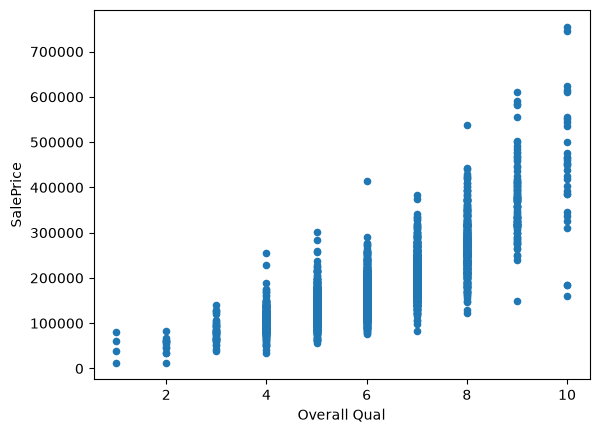

In [19]:
df.plot.scatter(x="Overall Qual", y="SalePrice")
plt.show()

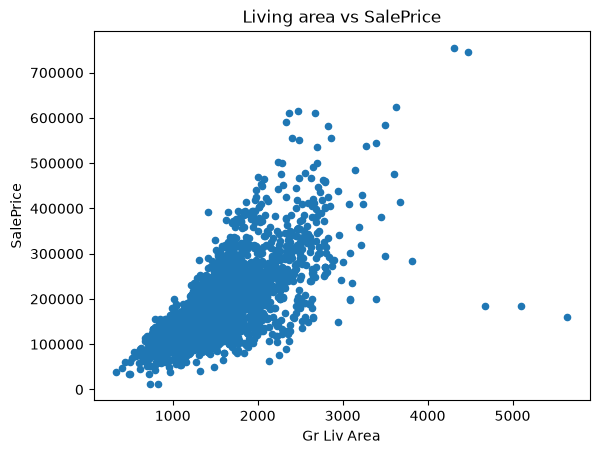

In [20]:
df.plot.scatter(x="Gr Liv Area", y="SalePrice")
plt.title("Living area vs SalePrice")
plt.show()

We can also take a look at how the house prices differ between the neighborhoods. Note: this is a text column, so it's not in the correlation list:

In [21]:
print("Median neighborhood price:")
df.groupby("Neighborhood")["SalePrice"].median().sort_values()

Median neighborhood price:


Neighborhood
MeadowV    88250.0
BrDale    106000.0
IDOTRR    106500.0
OldTown   119900.0
Edwards   125000.0
BrkSide   126750.0
Blueste   130500.0
Sawyer    135000.0
SWISU     136200.0
Landmrk   137000.0
NAmes     140000.0
NPkVill   143750.0
Mitchel   153500.0
SawyerW   180000.0
NWAmes    181000.0
Gilbert   183000.0
Blmngtn   191500.0
ClearCr   197500.0
Greens    198000.0
CollgCr   200000.0
Crawfor   200624.0
Somerst   225500.0
Timber    232106.5
Veenker   250250.0
GrnHill   280000.0
NoRidge   302000.0
NridgHt   317750.0
StoneBr   319000.0
Name: SalePrice, dtype: float64

 Quality and size have the strongest link to the price. In the `Overall Qual` plot the price climbs for every step up, but with more spread at the top levels. `Gr Liv Area` rises steadily with the price, but with even more spread.

The median price in `Neighborhood` goes from 88,250 in MeadowV to 319,000 in StoneBr, so location matters a lot and we want to keep it.

## Step 2 - Create training and test data

We use the same workflow as in Lecture 4: separate `X` and `y`, then split the data 80/20 with a fixed `random_state`.

In [22]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

# Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2344, 81)
Test set: (586, 81)


The data is now split 80/20, and because of the fixed `random_state` the split is the same every time we run the notebook. From now on we only work with the training data. The test set isn't touched until the final evaluation in step 6, so the models are tested on houses they've never seen.

## Step 3 - Prepare the data

The split in step 2 gave us four objects: `X_train`, `y_train`, `X_test` and `y_test`. The X tables have one row per house and one column per property, without the price. `y_train` and `y_test` hold the prices for the same rows. The models train only from `X_train` and `y_train`.

The first thing to do, to prepare the data, is to find out what the models can't handle. They can't do math on text like `NAmes`, and they stop if a value is missing, so we count both:

In [23]:
print("Text columns in X_train:", len(X_train.select_dtypes(exclude="number").columns))
print("Columns with missing values:", (X_train.isna().sum() > 0).sum())

Text columns in X_train: 43
Columns with missing values: 27


In [24]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
X_train.head()

X_train: (2344, 81)
y_train: (2344,)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition
2073,2074,905352180,60,RL,97.0,10029,Pave,NaN,IR1,Lvl,...,192,0,NaN,NaN,NaN,0,9,2007,WD,Normal
2754,2755,906382030,20,RL,86.0,11210,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,7,2006,New,Partial
1282,1283,535477090,20,RL,69.0,7590,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,5,2008,COD,Normal
1572,1573,916325080,20,RL,NaN,15498,Pave,NaN,IR1,Lvl,...,0,0,NaN,NaN,NaN,0,5,2008,COD,Abnorml
641,642,535302120,90,RL,76.0,9482,Pave,NaN,Reg,Lvl,...,0,0,NaN,NaN,NaN,0,12,2009,WD,Normal


The training set has 2344 houses and 81 columns, and `y_train` has one price for each of them. Even in these five houses we can see that both `MS Zoning` and `Sale Type` are text, and `Lot Frontage` is missing for house 1572.

We only drop columns here that don't say anything about the houses at all. `Order` and `PID` are unique per house, so they're just labels. Everything else stays for now, even weak columns like `Lot Frontage`, since choosing features is step 4.

In [25]:
# IMPORTANT! DO NOT RE-RUN AFTER INITIAL RUN!
X_train = X_train.copy()
X_test = X_test.copy()

# Order and PID are just labels
X_train = X_train.drop(columns=["Order", "PID"])
X_test = X_test.drop(columns=["Order", "PID"])

print("Columns left:", X_train.shape[1])

Columns left: 79


As we remember from 1a, `MS SubClass` is stored as a number, but it's a code for house type. We turn it into text so it's treated as a category and not as an amount.

In [26]:
X_train["MS SubClass"] = X_train["MS SubClass"].astype(str)
X_test["MS SubClass"] = X_test["MS SubClass"].astype(str)

print("MS SubClass:", X_train["MS SubClass"].dtype)

MS SubClass: str


Now the missing values. In 1c we saw that NaN in the text columns almost always means the house doesn't have the feature, like no alley or no pool, so we give them their own category called `"None"`.

In [32]:
text_cols = X_train.select_dtypes(exclude="number").columns

X_train[text_cols] = X_train[text_cols].fillna("None")
X_test[text_cols] = X_test[text_cols].fillna("None")

missing = X_train[text_cols].isna().sum()
print("missing values:", len(missing[missing > 0]))

missing values: 0


`Lot Frontage` is the other kind. The house has a frontage, the measurement just wasn't recorded, so we fill it with the median. The median is taken from the training data only, and the same value is used on the test set. If we used the whole dataset here, the test set would leak into the preprocessing.

In [28]:
lot_frontage_median = X_train["Lot Frontage"].median()

X_train["Lot Frontage"] = X_train["Lot Frontage"].fillna(lot_frontage_median)
X_test["Lot Frontage"] = X_test["Lot Frontage"].fillna(lot_frontage_median)

print("Median lot frontage:", lot_frontage_median)

Median lot frontage: 68.0


The numbers that are still missing are areas and counts for things the house doesn't have, like a garage or a basement, so 0 is the right value for them.

In [29]:
num_cols = X_train.select_dtypes(include="number").columns

X_train[num_cols] = X_train[num_cols].fillna(0)
X_test[num_cols] = X_test[num_cols].fillna(0)

missing = X_train.isna().sum()
print(missing[missing > 0])

Series([], dtype: int64)


Last, the text has to become numbers. One-hot encoding gives one 0/1 column per category, so `Neighborhood` turns into 28 columns where only one of them is 1 for each house.

The two sets have to end up with the same columns. Rare categories like the Landmrk neighborhood only exist on one side of the split, so `reindex` gives the test set the same columns in the same order, with 0 where a category is missing.

In [30]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

print("Before aligning:", X_train.shape, X_test.shape)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("After aligning:", X_train.shape, X_test.shape)

Before aligning: (2344, 330) (586, 294)
After aligning: (2344, 330) (586, 330)


We handled the missing values based on what they mean. In the text columns NaN mostly means the house doesn't have the feature, so they became their own category `"None"`, and the same goes for the numbers, where a missing garage or basement area became 0. `Lot Frontage` was different, because the value just isn't recorded, so we used the median from the training data.

The text columns were one-hot encoded, which took us from 78 to 328 columns. We didn't scale the numbers. The trees don't care about scale, and linear regression gives the same predictions with or without it.

Everything was learned from the training data and then applied to the test set in the same way.